In [1]:
import pandas as  pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("311_Service_Requests.csv", low_memory=False)

In [3]:
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [4]:
list(df.columns)

['Unique Key',
 'Created Date',
 'Closed Date',
 'Agency',
 'Agency Name',
 'Complaint Type',
 'Descriptor',
 'Location Type',
 'Incident Zip',
 'Incident Address',
 'Street Name',
 'Cross Street 1',
 'Cross Street 2',
 'Intersection Street 1',
 'Intersection Street 2',
 'Address Type',
 'City',
 'Landmark',
 'Facility Type',
 'Status',
 'Due Date',
 'Resolution Description',
 'Resolution Action Updated Date',
 'Community Board',
 'Borough',
 'X Coordinate (State Plane)',
 'Y Coordinate (State Plane)',
 'Park Facility Name',
 'Park Borough',
 'School Name',
 'School Number',
 'School Region',
 'School Code',
 'School Phone Number',
 'School Address',
 'School City',
 'School State',
 'School Zip',
 'School Not Found',
 'School or Citywide Complaint',
 'Vehicle Type',
 'Taxi Company Borough',
 'Taxi Pick Up Location',
 'Bridge Highway Name',
 'Bridge Highway Direction',
 'Road Ramp',
 'Bridge Highway Segment',
 'Garage Lot Name',
 'Ferry Direction',
 'Ferry Terminal Name',
 'Latitude',


In [5]:
df.shape

(364558, 53)

In [6]:
df.isnull().sum()

Unique Key                             0
Created Date                           0
Closed Date                         2381
Agency                                 0
Agency Name                            0
Complaint Type                         0
Descriptor                          6501
Location Type                        133
Incident Zip                        2998
Incident Address                   51699
Street Name                        51699
Cross Street 1                     57188
Cross Street 2                     57805
Intersection Street 1             313438
Intersection Street 2             314046
Address Type                        3252
City                                2997
Landmark                          364183
Facility Type                       2389
Status                                 0
Due Date                               3
Resolution Description                 0
Resolution Action Updated Date      2402
Community Board                        0
Borough         

<Axes: >

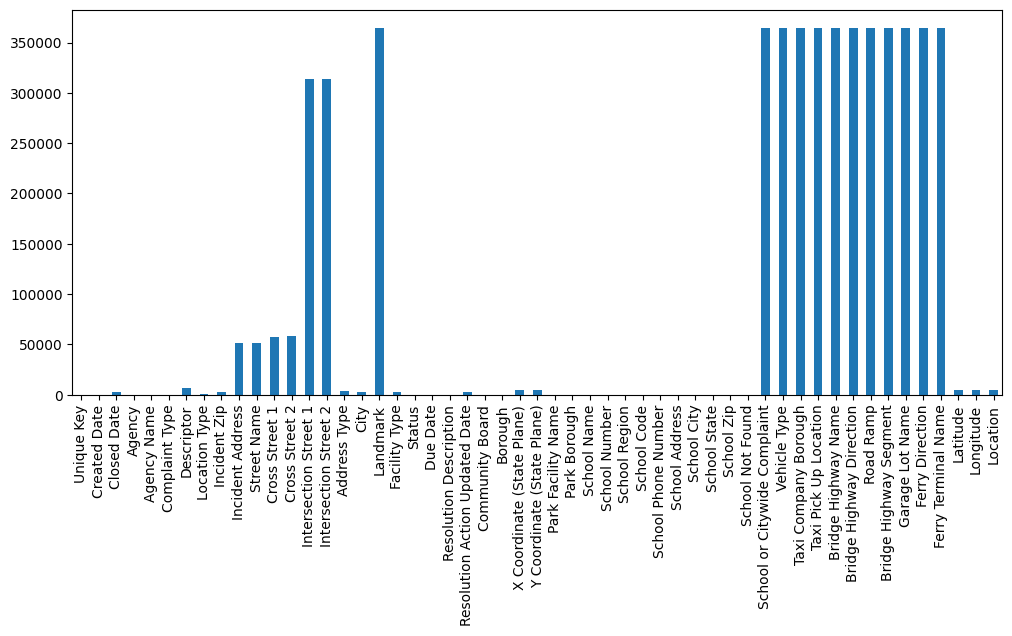

In [7]:
#Draw a frequency plot to show the number of null values in each column of the DataFrame
df.isnull().sum().plot(kind='bar',figsize=(12,5))

In [8]:
#finding out empty columns
empty_cols  = df.columns[df.isnull().all()]
empty_cols 

Index(['School or Citywide Complaint', 'Vehicle Type', 'Taxi Company Borough',
       'Taxi Pick Up Location', 'Garage Lot Name'],
      dtype='object')

In [9]:
#Dropping Empty Columns
df = df.drop(['School or Citywide Complaint', 'Vehicle Type', 'Taxi Company Borough',
       'Taxi Pick Up Location', 'Garage Lot Name'],axis=1)

In [10]:
df.shape

(364558, 48)

In [11]:
#Remove the records whose Closed Date values are null
df = df.dropna(subset=['Closed Date'])

In [12]:
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')

C:\Users\surya\AppData\Local\Temp\ipykernel_7732\1175343188.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')


In [13]:
df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')

C:\Users\surya\AppData\Local\Temp\ipykernel_7732\1584812765.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')


In [14]:
#Analyze the date column, and remove entries that have an incorrect timeline
df = df[df['Closed Date'] >= df['Created Date']]

In [15]:
#Calculate the time elapsed in closed and creation date
df['Request_Closing_Time'] =  df['Closed Date'] - df['Created Date']

In [16]:
#Convert the calculated date to seconds to get a better representation
df['Request_Closing_Time'] = df['Request_Closing_Time'].dt.total_seconds()

In [17]:
#View the descriptive statistics for the newly created column
df['Request_Closing_Time'].describe()

count    3.621770e+05
mean     1.511330e+04
std      2.110255e+04
min      6.100000e+01
25%      4.533000e+03
50%      9.616000e+03
75%      1.887800e+04
max      2.134342e+06
Name: Request_Closing_Time, dtype: float64

In [18]:
#Check the number of null values in the Complaint_Type and City columns
df['City'].isnull().sum()

np.int64(674)

In [19]:
#Impute the NA value with Unknown City
df["City"].fillna("Unknown City",inplace=True)

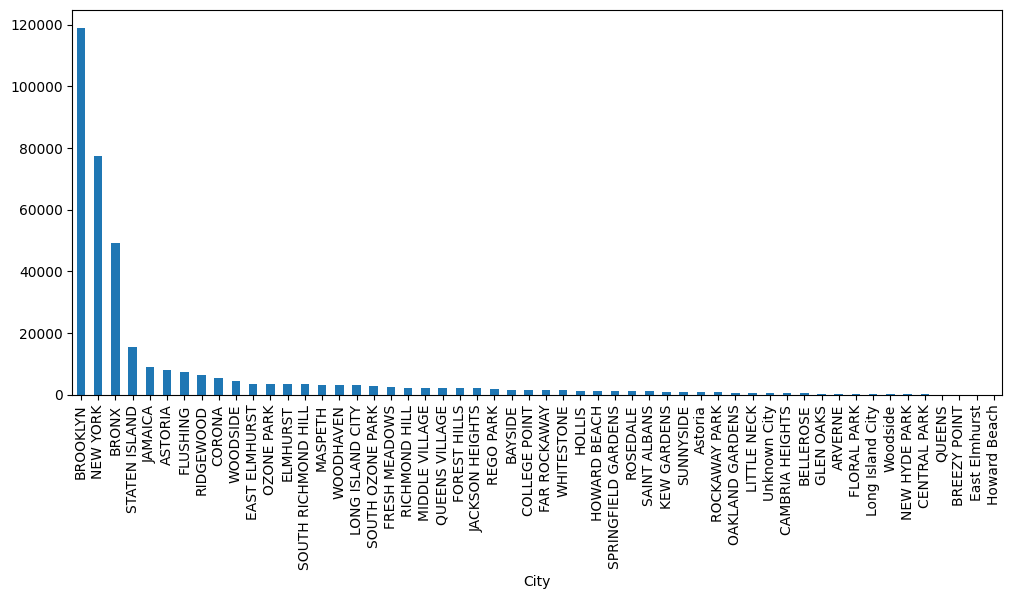

In [20]:
#Draw a frequency plot for the complaints in each city
df['City'].value_counts().plot(kind="bar",figsize=(12,5))
plt.show()

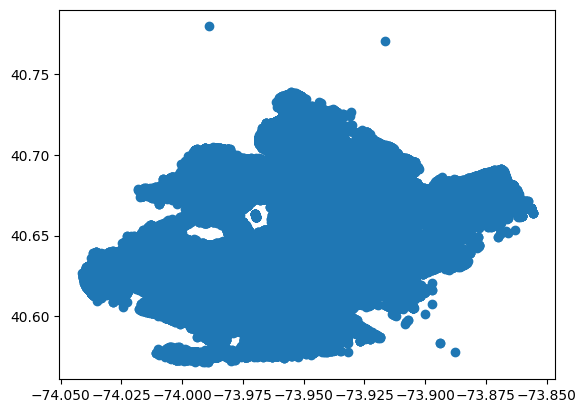

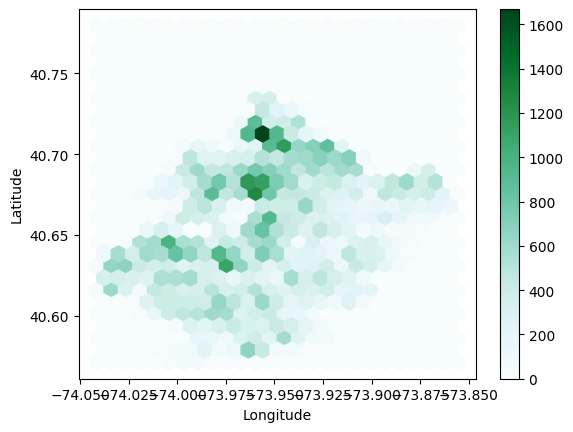

In [21]:
#Create a scatter and hexbin plot of the concentration of complaints across Brooklyn

brooklyn = df[df['City'] == 'BROOKLYN']

#SCATTER 
plt.scatter(brooklyn['Longitude'],brooklyn['Latitude'])
plt.show()

#HEXBIN
brooklyn.plot.hexbin(x='Longitude',y='Latitude',gridsize=25)
plt.show()

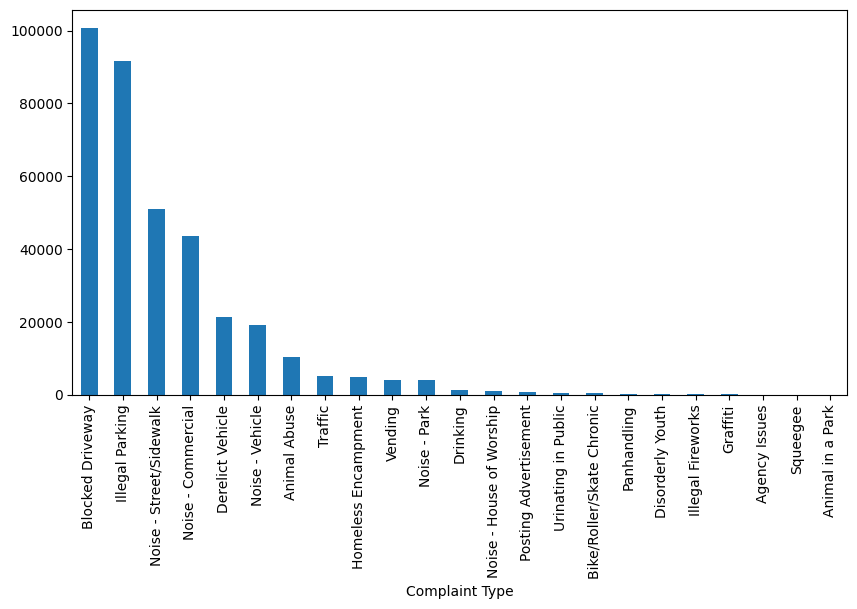

In [22]:
#Plot a bar graph to show the types of complaints
df['Complaint Type'].value_counts().plot(kind='bar',figsize = (10,5))
plt.show()

In [23]:
#Check the frequency of various types of complaints for New York City
NYC = df[df['City'] == 'NEW YORK']
NYC['Complaint Type'].value_counts()

Complaint Type
Noise - Street/Sidewalk      22245
Noise - Commercial           18686
Illegal Parking              14549
Noise - Vehicle               6294
Homeless Encampment           3060
Blocked Driveway              2705
Vending                       2638
Animal Abuse                  1941
Traffic                       1769
Noise - Park                  1243
Derelict Vehicle               695
Drinking                       321
Urinating in Public            264
Bike/Roller/Skate Chronic      254
Noise - House of Worship       222
Panhandling                    206
Disorderly Youth                81
Posting Advertisement           49
Illegal Fireworks               38
Graffiti                        25
Squeegee                         4
Name: count, dtype: int64

In [24]:
#Find the top 10 complaint types
df['Complaint Type'].value_counts().head(10)

Complaint Type
Blocked Driveway           100624
Illegal Parking             91716
Noise - Street/Sidewalk     51139
Noise - Commercial          43751
Derelict Vehicle            21518
Noise - Vehicle             19301
Animal Abuse                10530
Traffic                      5196
Homeless Encampment          4879
Vending                      4185
Name: count, dtype: int64

In [25]:
#Display the various types of complaints in each city
pd.crosstab(df['City'],df['Complaint Type'])

Complaint Type,Agency Issues,Animal Abuse,Animal in a Park,Bike/Roller/Skate Chronic,Blocked Driveway,Derelict Vehicle,Disorderly Youth,Drinking,Graffiti,Homeless Encampment,...,Noise - House of Worship,Noise - Park,Noise - Street/Sidewalk,Noise - Vehicle,Panhandling,Posting Advertisement,Squeegee,Traffic,Urinating in Public,Vending
City,,,,,,,,,,,,,,,,,,,,,
ARVERNE,0,46,0,0,50,32,2,1,1,4,...,14,2,29,10,1,0,0,1,1,1
ASTORIA,0,170,0,16,3436,426,5,43,4,32,...,21,64,409,236,2,3,0,60,10,57
Astoria,0,0,0,0,159,14,0,0,0,0,...,0,0,145,0,0,0,0,0,0,0
BAYSIDE,0,53,0,0,514,231,2,1,3,2,...,3,4,17,24,0,0,0,9,0,2
BELLEROSE,0,15,0,1,138,120,2,1,0,1,...,1,1,13,11,1,1,0,9,1,0
BREEZY POINT,0,2,0,0,3,3,0,1,0,0,...,0,0,1,1,0,0,0,0,0,0
BRONX,0,1971,0,22,17062,2402,66,206,15,275,...,90,548,9144,3556,20,18,0,427,54,433
BROOKLYN,0,3191,0,124,36445,6257,79,291,60,948,...,389,1575,13982,5965,49,58,0,1258,155,575
CAMBRIA HEIGHTS,0,15,0,0,177,148,0,0,0,6,...,2,0,29,100,0,0,0,7,0,0


In [26]:
#Create a DataFrame, df_new, which contains cities as columns and complaint types in rows
df_new = pd.crosstab(df['Complaint Type'],df['City'])
df_new

City,ARVERNE,ASTORIA,Astoria,BAYSIDE,BELLEROSE,BREEZY POINT,BRONX,BROOKLYN,CAMBRIA HEIGHTS,CENTRAL PARK,...,SOUTH OZONE PARK,SOUTH RICHMOND HILL,SPRINGFIELD GARDENS,STATEN ISLAND,SUNNYSIDE,Unknown City,WHITESTONE,WOODHAVEN,WOODSIDE,Woodside
Complaint Type,,,,,,,,,,,,,,,,,,,,,
Agency Issues,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,8,0,0,0,0
Animal Abuse,46,170,0,53,15,2,1971,3191,15,0,...,74,40,42,786,40,1,43,57,111,0
Animal in a Park,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bike/Roller/Skate Chronic,0,16,0,0,1,0,22,124,0,0,...,1,1,0,10,2,2,4,2,5,0
Blocked Driveway,50,3436,159,514,138,3,17062,36445,177,0,...,1202,1946,330,2845,278,86,279,1363,2038,27
Derelict Vehicle,32,426,14,231,120,3,2402,6257,148,0,...,425,356,267,2184,17,63,279,369,298,8
Disorderly Youth,2,5,0,2,2,0,66,79,0,0,...,2,2,0,25,2,0,1,0,1,0
Drinking,1,43,0,1,1,1,206,291,0,0,...,14,25,6,188,12,3,3,4,15,0
Graffiti,1,4,0,3,0,0,15,60,0,0,...,2,0,0,6,1,0,1,0,4,0


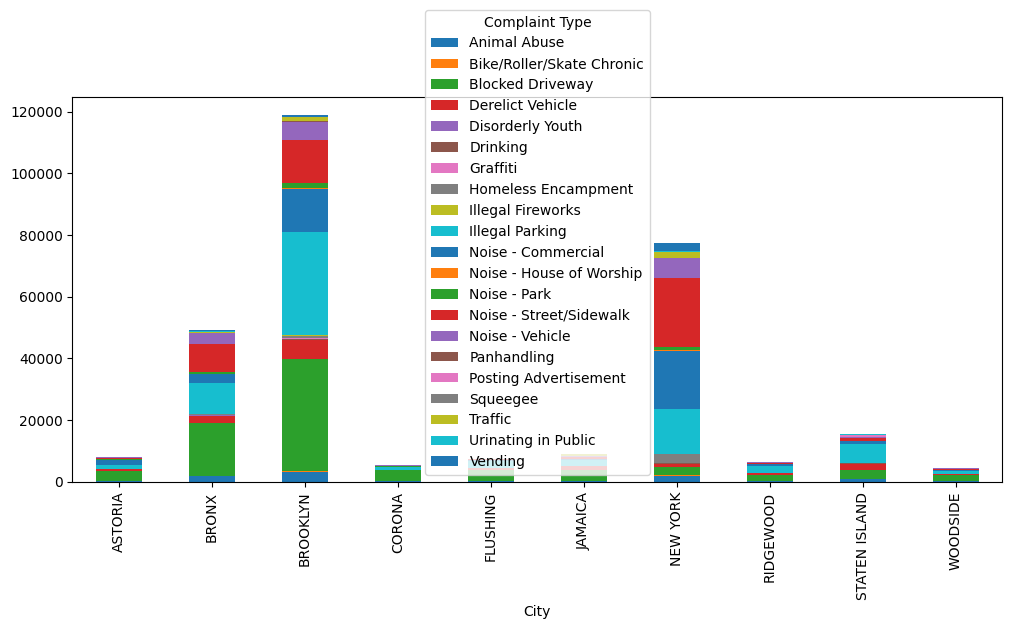

In [33]:
#Draw another chart that shows the types of complaints in each city in a single chart, where different colors show the different types of complaints

top_cities = df['City'].value_counts().head(10).index
df_filtered = df[df['City'].isin(top_cities)]

df_new = pd.crosstab(df_filtered['City'], df_filtered['Complaint Type'])
df_new.plot(kind='bar', stacked=True,figsize = (12,5))
plt.show()

In [41]:
#Sort the complaint types based on the average Request_Closing_Timegrouping them for different locations

(df.groupby(['City','Complaint Type']))['Request_Closing_Time'].mean().sort_values().round(2)

City                 Complaint Type           
ARVERNE              Drinking                         859.0
RIDGEWOOD            Posting Advertisement            895.0
EAST ELMHURST        Bike/Roller/Skate Chronic        908.0
OZONE PARK           Illegal Fireworks               1191.0
QUEENS               Urinating in Public             1226.0
                                                    ...    
OAKLAND GARDENS      Homeless Encampment           103156.0
SOUTH RICHMOND HILL  Bike/Roller/Skate Chronic     111277.0
BELLEROSE            Homeless Encampment           140930.0
QUEENS VILLAGE       Graffiti                      191995.0
QUEENS               Animal in a Park             1212634.0
Name: Request_Closing_Time, Length: 792, dtype: float64

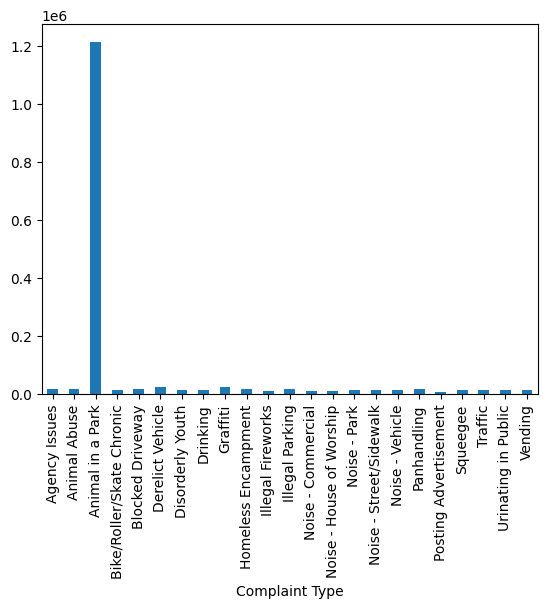

In [45]:
#Visualize the average of Request_Closing_Time
df.groupby('Complaint Type')['Request_Closing_Time'].mean().plot(kind='bar')
plt.show()

In [47]:
!pip install scipy



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
    --------------------------------------- 0.8/37.3 MB 6.1 MB/s eta 0:00:06
   - -------------------------------------- 1.8/37.3 MB 5.5 MB/s eta 0:00:07
   --- ------------------------------------ 3.1/37.3 MB 5.6 MB/s eta 0:00:07
   ---- ----------------------------------- 4.2/37.3 MB 5.8 MB/s eta 0:00:06
   ----- ---------------------------------- 5.2/37.3 MB 5.5 MB/s eta 0:00:06
   ------ --------------------------------- 6.3/37.3 MB 5.5 MB/s eta 0:00:06
   ------- -------------------------------- 7.3/37.3 MB 5.4 MB/s eta 0:00:06
   -------- ------------------------------- 8.4/37.3 MB 5.4 MB/s eta 0:00:06
   ---------- ----------------------------- 9.7/37.3 MB 5.4 MB/s eta 0:00:06
   ----------- ---------------------------- 10.7/37.3 MB 5.4 MB/s eta 0:00:05
   ------------ --------------------------- 12.1/37.3 MB 5.5 MB/s eta 0:00:05
   -------------- ------------------------- 13.4/37.3 MB 5.5 MB/s eta 0:00:05
   

In [48]:
#Perform a Kruskal-WallisH test

from scipy.stats import kruskal

groups = []
for name, group in df.groupby('Complaint Type'):
    groups.append(group['Request_Closing_Time'].values)

stat, p = kruskal(*groups)

print("P-value:", p)

P-value: 0.0
